# 04 — Avaliação final

Análise pós-treino do modelo vencedor:

- Re-roda predições no holdout (sem retreinar).
- Gráfico predito vs real.
- Análise de resíduos.
- Tabela comparativa final (Ridge baseline vs RF vs XGB).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.data import load_data, split_holdout
from src.predict import load_model
from src.preprocessing import prepare_features

metrics = json.loads((ROOT / 'docs' / 'metrics.json').read_text(encoding='utf-8'))
metrics['winner']

'xgb'

## Predições no holdout (mesmo split do treino)

In [2]:
treino, _ = load_data()
_, holdout = split_holdout(treino, test_size=0.2, random_state=42)
X_h, y_h_log = prepare_features(holdout)

model = load_model()
pred_log = model.predict(X_h)
pred = np.expm1(pred_log)
actual = np.expm1(y_h_log).values

rmsle = float(np.sqrt(mean_squared_error(y_h_log, pred_log)))
mae = float(mean_absolute_error(actual, pred))
r2 = float(r2_score(actual, pred))
print(f'RMSLE: {rmsle:.4f} · MAE: US$ {mae:,.0f} · R²: {r2:.4f}')

RMSLE: 0.1391 · MAE: US$ 17,195 · R²: 0.8834


## Predito vs Real

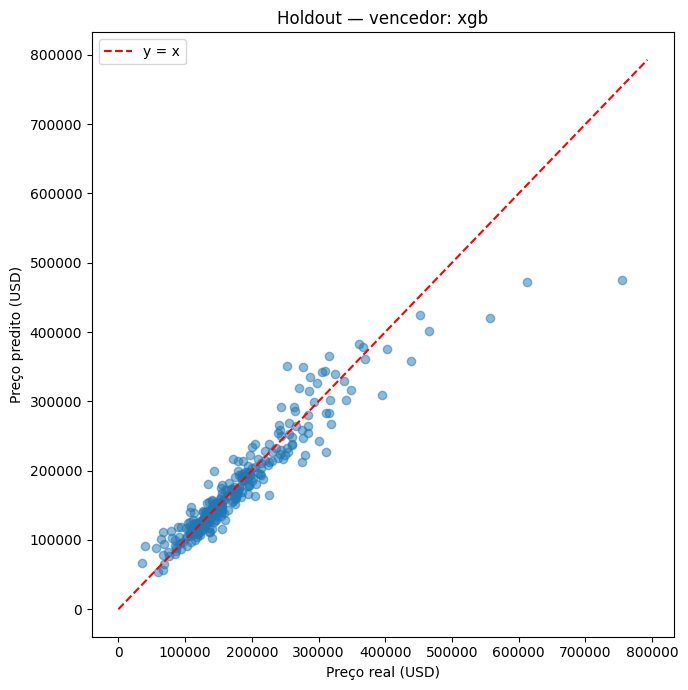

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual, pred, alpha=0.5)
limit = max(actual.max(), pred.max()) * 1.05
ax.plot([0, limit], [0, limit], 'r--', label='y = x')
ax.set_xlabel('Preço real (USD)')
ax.set_ylabel('Preço predito (USD)')
ax.set_title(f'Holdout — vencedor: {metrics["winner"]}')
ax.legend()
plt.tight_layout()
plt.show()

## Análise de resíduos

Resíduo = real − predito. Em escala de log e em USD.

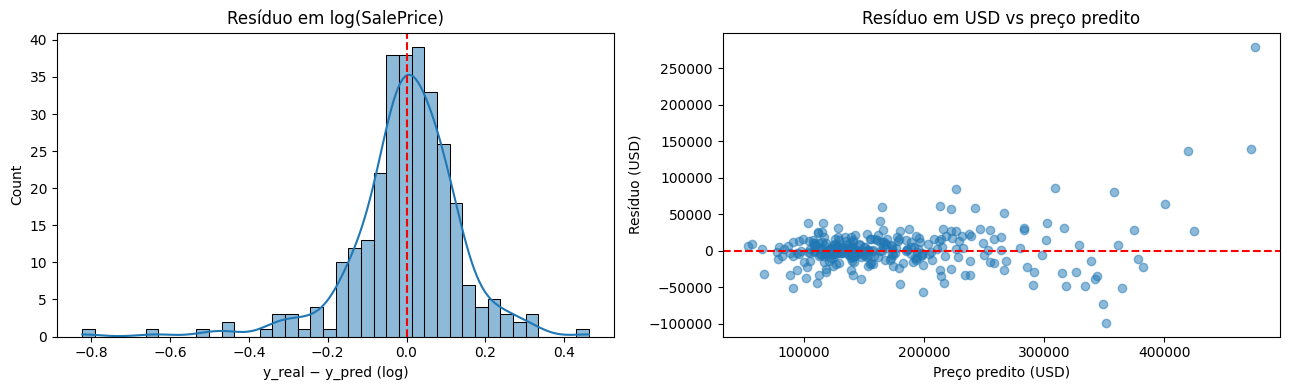

média resíduo (log): -0.0015
std resíduo (log):   0.1391
média resíduo (USD): US$ +2,857
mediana abs resíduo (USD): US$ 10,631


In [4]:
resid_log = y_h_log.values - pred_log
resid_usd = actual - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(resid_log, bins=40, kde=True, ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Resíduo em log(SalePrice)')
axes[0].set_xlabel('y_real − y_pred (log)')

axes[1].scatter(pred, resid_usd, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Resíduo em USD vs preço predito')
axes[1].set_xlabel('Preço predito (USD)')
axes[1].set_ylabel('Resíduo (USD)')
plt.tight_layout()
plt.show()

print(f'média resíduo (log): {resid_log.mean():+.4f}')
print(f'std resíduo (log):   {resid_log.std():.4f}')
print(f'média resíduo (USD): US$ {resid_usd.mean():+,.0f}')
print(f'mediana abs resíduo (USD): US$ {np.median(np.abs(resid_usd)):,.0f}')

## Comparação final: Ridge vs RF vs XGB

Treina o Ridge baseline rapidamente para ter os 3 lado a lado.

In [5]:
X_dev, y_dev = prepare_features(split_holdout(treino, random_state=42)[0])
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_dev, y_dev)
ridge_pred_log = ridge.predict(X_h)
ridge_pred = np.expm1(ridge_pred_log)
ridge_metrics = {
    'rmsle': float(np.sqrt(mean_squared_error(y_h_log, ridge_pred_log))),
    'mae_usd': float(mean_absolute_error(actual, ridge_pred)),
    'r2': float(r2_score(actual, ridge_pred)),
}

tabela = pd.DataFrame({
    'Ridge (baseline)': ridge_metrics,
    'RandomForest': {k: metrics['comparison']['rf'][k] for k in ('rmsle', 'mae_usd', 'r2')},
    'XGBoost': {k: metrics['comparison']['xgb'][k] for k in ('rmsle', 'mae_usd', 'r2')},
}).T
tabela.style.format({'rmsle': '{:.4f}', 'mae_usd': 'US$ {:,.0f}', 'r2': '{:.4f}'})

,rmsle,mae_usd,r2
Ridge (baseline),0.1395,"US$ 18,595",0.8847
RandomForest,0.1452,"US$ 17,307",0.8831
XGBoost,0.1391,"US$ 17,195",0.8834


## Conclusão

- Vencedor: **XGBoost** (menor RMSLE no CV).
- O ganho sobre RF é modesto, mas consistente CV+holdout.
- Ridge é um piso útil: indica que features lineares já levam longe;
  o ganho dos boosters vem em interações não-lineares e qualidade nos extremos.
- Resíduos em log estão ~simétricos centrados em zero, sem skew óbvio.